# Echo-Lorentzian cutoff / amplitude / FWHM results

This notebook opens one **single-cutoff detuning-frequency sweep first**, then the complete cutoff–amplitude FWHM map, and finally compares it with the older echo-Lorentzian cutoff sweep. It only reads existing data; it does not connect to hardware or update profiles.

## 1. Setup and result selection

Change `SINGLE_CUTOFF_INDEX` to open another one-cutoff sweep. Indices are 1-based and follow the run manifest.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import numpy as np
import pandas as pd
from IPython.display import Image, display

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.figsize': (10, 6), 'figure.dpi': 120})

def find_repo_root(start=Path.cwd()):
    for candidate in (start, *start.parents):
        if (candidate / 'data').is_dir() and (candidate / 'Projects').is_dir():
            return candidate
    raise FileNotFoundError('Run this notebook from inside the opx1000-codes repository.')

REPO_ROOT = find_repo_root()
CURRENT_RUN = REPO_ROOT / 'data/cutoff_amp_fwhm_map/20260712_171809_single_cutoff_full'
OLDER_RUN = REPO_ROOT / 'data/echo_lorentzian_cutoff_sweep/20260630_173829'
SINGLE_CUTOFF_INDEX = 7

print('Repository :', REPO_ROOT)
print('Current map:', CURRENT_RUN)
print('Older sweep:', OLDER_RUN)

Repository : c:\Users\owner\Developer\opx1000-codes
Current map: c:\Users\owner\Developer\opx1000-codes\data\cutoff_amp_fwhm_map\20260712_171809_single_cutoff_full
Older sweep: c:\Users\owner\Developer\opx1000-codes\data\echo_lorentzian_cutoff_sweep\20260630_173829


In [2]:
def require(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(path)
    return path

def read_json(path):
    with require(path).open(encoding='utf-8') as handle:
        return json.load(handle)

def clean_results(frame):
    frame = frame.copy()
    numeric = [
        'cutoff', 'amp_prefactor', 'full_amp_v', 'rabi_frequency_mhz',
        'gaussian_center_hz', 'fwhm_hz', 'fwhm_mhz',
        'fit_abs_amplitude', 'fit_r_squared'
    ]
    for column in numeric:
        if column in frame:
            frame[column] = pd.to_numeric(frame[column], errors='coerce')
    return frame.replace([np.inf, -np.inf], np.nan)

current_manifest = read_json(CURRENT_RUN / 'manifest.json')
older_manifest = read_json(OLDER_RUN / 'manifest.json')
current_fit = clean_results(pd.read_csv(require(CURRENT_RUN / 'cutoff_amp_fwhm_map_fit_results.csv')))
current_best = clean_results(pd.read_csv(require(CURRENT_RUN / 'cutoff_amp_fwhm_map_best_signal.csv')))
older_fit = clean_results(pd.read_csv(require(OLDER_RUN / 'cutoff_sweep_fit_results.csv')))
older_best = clean_results(pd.read_csv(require(OLDER_RUN / 'cutoff_sweep_best_signal.csv')))

overview = pd.DataFrame([
    {
        'result': 'current cutoff–amplitude map',
        'created': current_manifest.get('created_at'),
        'cutoffs': current_fit['cutoff'].nunique(),
        'amplitudes': current_fit['amp_prefactor'].nunique(),
        'fit rows': len(current_fit),
        'valid FWHM': current_fit['fwhm_mhz'].notna().sum(),
    },
    {
        'result': 'older echo-Lorentzian cutoff sweep',
        'created': older_manifest.get('created_at'),
        'cutoffs': older_fit['cutoff'].nunique(),
        'amplitudes': older_fit['amp_prefactor'].nunique(),
        'fit rows': len(older_fit),
        'valid FWHM': older_fit['fwhm_mhz'].notna().sum(),
    },
])
display(overview)

,result,created,cutoffs,amplitudes,fit rows,valid FWHM
0,current cutoff–amplitude map,2026-07-12T18:48:35.052801+03:00,20,25,500,394
1,older echo-Lorentzian cutoff sweep,2026-06-30T17:40:05.451320+03:00,20,20,400,14


## 2. One simple detuning-frequency sweep

This is the saved raw spectroscopy view for one cutoff. The horizontal axis is detuning frequency; each row is a drive amplitude. Change `SINGLE_CUTOFF_INDEX` above to inspect a different cutoff.

Run 7/20 — cutoff = 0.0141892


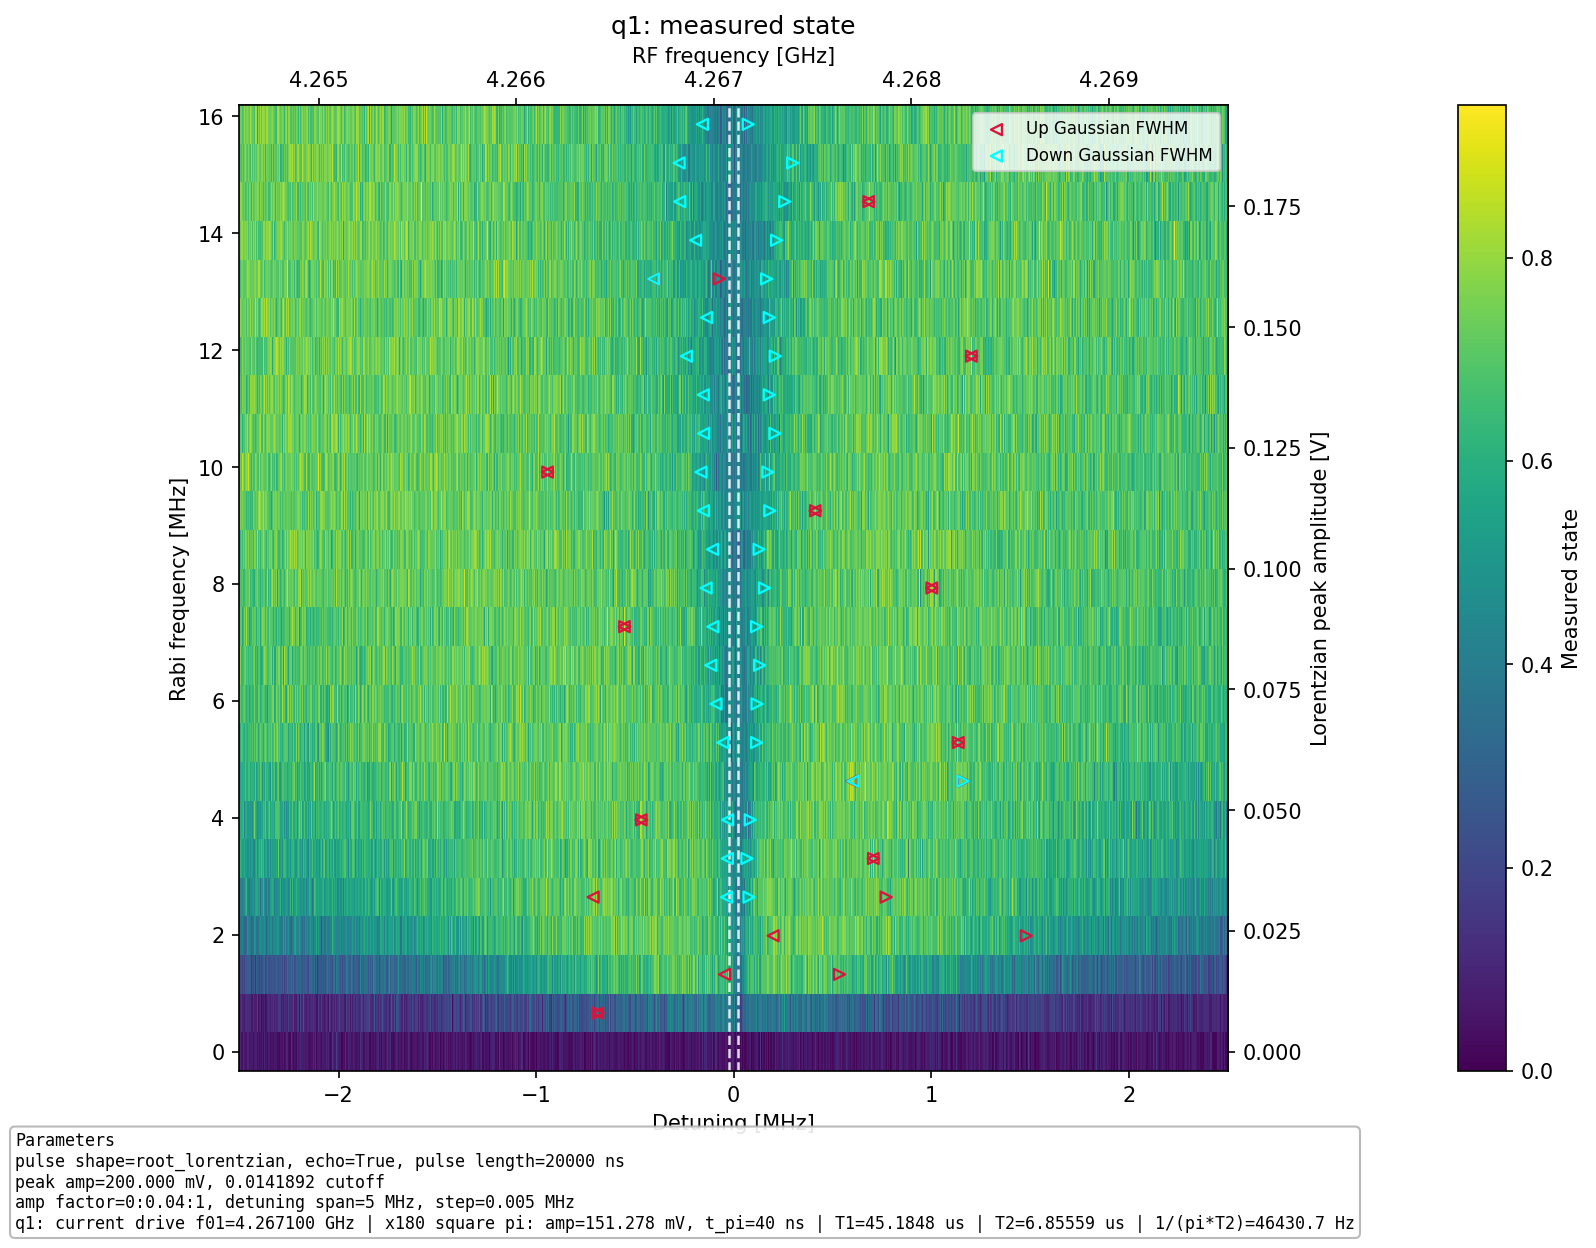

In [3]:
runs = current_manifest['runs']
if not 1 <= SINGLE_CUTOFF_INDEX <= len(runs):
    raise ValueError(f'SINGLE_CUTOFF_INDEX must be between 1 and {len(runs)}')

single_run = runs[SINGLE_CUTOFF_INDEX - 1]
single_dir = Path(single_run['output_dir'])
if not single_dir.is_absolute():
    single_dir = REPO_ROOT / single_dir
single_images = sorted((single_dir / 'individual_figures').glob('*.png'))
if not single_images:
    raise FileNotFoundError(f'No individual sweep figure in {single_dir}')

print(f"Run {SINGLE_CUTOFF_INDEX}/{len(runs)} — cutoff = {single_run['cutoff']:.6g}")
display(Image(filename=str(single_images[0])))

## 3. Full cutoff–amplitude sweep results

The heatmap below is rebuilt from the fitted CSV. Empty cells are failed or unavailable fits. Color is logarithmic so both narrow and broad fitted widths remain visible.

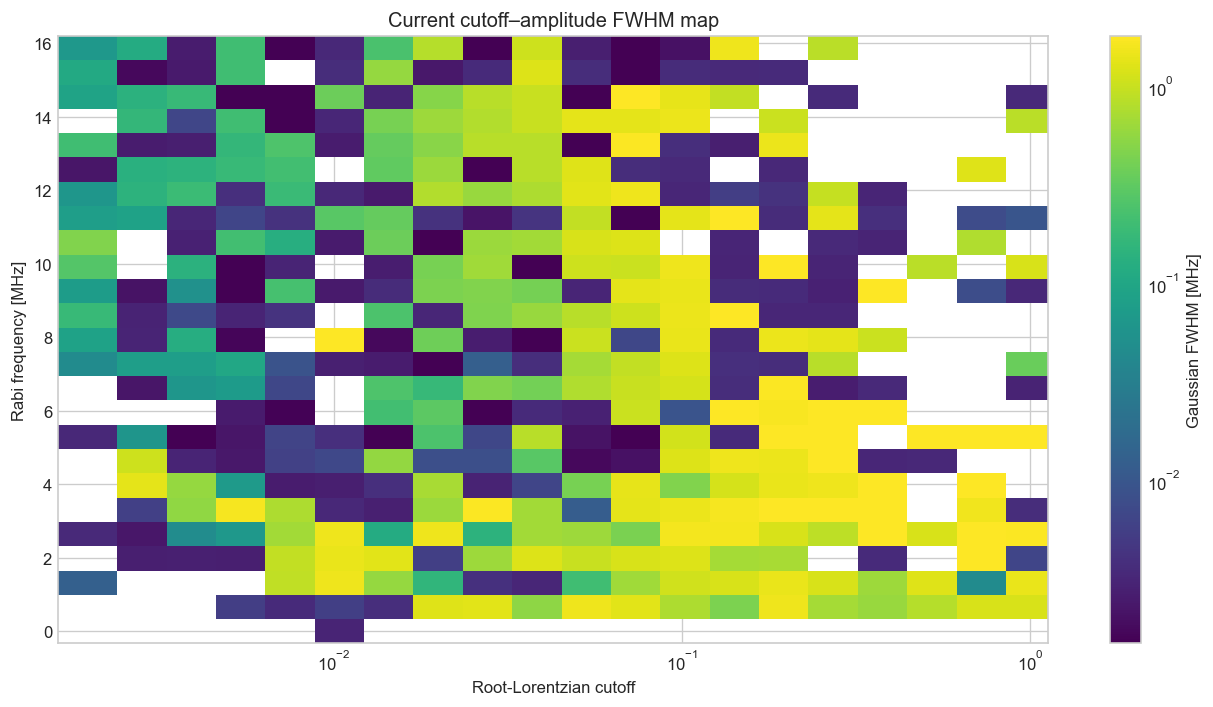

In [4]:
def plot_fwhm_map(frame, title):
    usable = frame.dropna(subset=['cutoff', 'rabi_frequency_mhz', 'fwhm_mhz'])
    usable = usable[usable['fwhm_mhz'] > 0]
    pivot = usable.pivot_table(
        index='rabi_frequency_mhz', columns='cutoff', values='fwhm_mhz', aggfunc='median'
    ).sort_index().sort_index(axis=1)
    if pivot.empty:
        raise ValueError('No positive fitted FWHM values are available.')

    values = np.ma.masked_invalid(pivot.to_numpy())
    positive = values.compressed()
    lo, hi = np.nanpercentile(positive, [5, 95])
    lo = max(lo, np.nanmin(positive))
    hi = max(hi, lo * 1.01)

    fig, ax = plt.subplots(figsize=(11, 6))
    mesh = ax.pcolormesh(
        pivot.columns.to_numpy(), pivot.index.to_numpy(), values,
        shading='nearest', cmap='viridis', norm=LogNorm(vmin=lo, vmax=hi)
    )
    ax.set_xscale('log')
    ax.set_xlabel('Root-Lorentzian cutoff')
    ax.set_ylabel('Rabi frequency [MHz]')
    ax.set_title(title)
    fig.colorbar(mesh, ax=ax, label='Gaussian FWHM [MHz]')
    fig.tight_layout()
    return fig, ax

plot_fwhm_map(current_fit, 'Current cutoff–amplitude FWHM map')
plt.show()

In [ ]:
current_valid = current_best.dropna(subset=['cutoff', 'fwhm_mhz', 'rabi_frequency_mhz']).sort_values('cutoff')
older_valid = older_best.dropna(subset=['cutoff', 'fwhm_mhz', 'rabi_frequency_mhz']).sort_values('cutoff')

fig, axes = plt.subplots(2, 1, figsize=(10, 9), sharex=True)
for data, label, marker in [
    (current_valid, 'current map', 'o'),
    (older_valid, 'older sweep', 's'),
]:
    axes[0].plot(data['cutoff'], data['fwhm_mhz'], marker=marker, label=label)
    axes[1].plot(data['cutoff'], data['rabi_frequency_mhz'], marker=marker, label=label)

axes[0].set_ylabel('Best-signal FWHM [MHz]')
axes[1].set_ylabel('Selected Rabi frequency [MHz]')
axes[1].set_xlabel('Root-Lorentzian cutoff')
for ax in axes:
    ax.set_xscale('log')
    ax.legend()
axes[0].set_title('Current map compared with the older echo-Lorentzian sweep')
fig.tight_layout()
plt.show()

## 4. Original saved summary figures

These are the analysis figures saved by each experiment, useful for checking the notebook reconstruction against the original output.

In [ ]:
saved_figures = [
    ('Current summary', CURRENT_RUN / 'cutoff_amp_fwhm_map_summary.png'),
    ('Current per-cutoff traces', CURRENT_RUN / 'cutoff_amp_fwhm_map_per_cutoff_traces.png'),
    ('Older summary', OLDER_RUN / 'cutoff_sweep_summary.png'),
    ('Older per-cutoff traces', OLDER_RUN / 'cutoff_sweep_per_cutoff_traces.png'),
]
for label, path in saved_figures:
    if path.exists():
        print(label)
        display(Image(filename=str(path)))
    else:
        print(f'{label}: not present ({path.name})')